In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

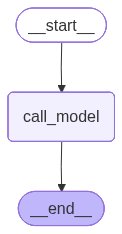

In [12]:
graph

In [20]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Vinil."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 94
What is my name?
I've already mentioned that I don't have any information about your name. Each time you interact with me, it's a new conversation, and I don't retain any information from previous conversations. If you'd like to introduce yourself or provide a name, I'd be happy to chat with you.
Hi, my name is Vinil.


"Nice to meet you, Vinil. I'm happy to chat with you now. Is there something specific you'd like to talk about, or would you like some recommendations or information on a particular topic?"

In [21]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 148
I've already mentioned that I don't have any information about your name. Each time you interact with me, it's a new conversation, and I don't retain any information from previous conversations. If you'd like to introduce yourself or provide a name, I'd be happy to chat with you.
Hi, my name is Vinil.
Nice to meet you, Vinil. I'm happy to chat with you now. Is there something specific you'd like to talk about, or would you like some recommendations or information on a particular topic?
I am learning LangGraph.


"LangGraph is a machine learning model for natural language processing, specifically designed for graph-based tasks. It's a relatively new and exciting area of research.\n\nWhat specifically are you learning about LangGraph, Vinil? Are you trying to implement it, or learning about its theoretical aspects? Are you working on a project that involves LangGraph, or is it a topic of interest for personal learning?"

In [22]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 131
I am learning LangGraph.
LangGraph is a machine learning model for natural language processing, specifically designed for graph-based tasks. It's a relatively new and exciting area of research.

What specifically are you learning about LangGraph, Vinil? Are you trying to implement it, or learning about its theoretical aspects? Are you working on a project that involves LangGraph, or is it a topic of interest for personal learning?
Can you explain short term memory?


'In the context of natural language processing (NLP) and machine learning, short-term memory (STM) is a crucial component of some models, including LangGraph.\n\n**What is Short-Term Memory?**\n\nIn LangGraph, short-term memory refers to a buffer-like structure that temporarily stores and processes input elements (e.g., tokens, words, or even subgraphs) before they are either output or discarded.\n\nThink of STM as a "scratchpad" that holds a limited number of elements, allowing the model to manipulate and transform them before moving on to the next step.\n\n**How does STM work in LangGraph?**\n\nIn LangGraph, STM is typically implemented as a stack or a queue data structure. The model processes input elements one at a time, storing them in STM until they are either:\n\n1. Output (e.g., a token is output as part of a predicted sentence)\n2. Discarded (e.g., a token is no longer relevant to the current task)\n\nSTM enables LangGraph to maintain context and process hierarchical structure

In [26]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 102
What is my name?
I don't have any information about you, so I don't know your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you!
What is my name?


"I already told you, I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. If you'd like to share your name with me, I'd be happy to chat with you."

In [25]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Vinil.
------------------------------------------------------------------------------------------------------------------------
Nice to meet you, Vinil. I'm happy to chat with you. Is there something on your mind that you'd like to talk about, or would you like to engage in a casual conversation?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
LangGraph is a Python library for natural language processing and machine learning. It provides a comprehensive framework for building and training language models. Learning LangGraph can be a bit challenging, but with dedication and practice, you'll become proficient in no time.

What specifically are you trying to achieve with LangGraph? Are you working on a project, or is it for research purposes?
----------------